# Sales Forecasting Machine Learing (Basic to advance )

# load csv file  using pandas

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv("sales_data_sample.csv", encoding='latin1')

# Basic Information about data

In [18]:
data.head(5)

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [19]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   str    
 6   STATUS            2823 non-null   str    
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   str    
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   str    
 13  CUSTOMERNAME      2823 non-null   str    
 14  PHONE             2823 non-null   str    
 15  ADDRESSLINE1      2823 non-null   str    
 16  ADDRESSLINE2      302 non-null    str    
 17  CITY  

In [20]:
data.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='str')

In [21]:
data.shape

(2823, 25)

In [22]:
data.describe()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP
count,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.00000,2823.000000
mean,10258.725115,35.092809,83.658544,6.466171,3553.889072,2.717676,7.092455,2003.81509,100.715551
std,92.085478,9.741443,20.174277,4.225841,1841.865106,1.203878,3.656633,0.69967,40.187912
min,10100.000000,6.000000,26.880000,1.000000,482.130000,1.000000,1.000000,2003.00000,33.000000
25%,10180.000000,27.000000,68.860000,3.000000,2203.430000,2.000000,4.000000,2003.00000,68.000000
50%,10262.000000,35.000000,95.700000,6.000000,3184.800000,3.000000,8.000000,2004.00000,99.000000
75%,10333.500000,43.000000,100.000000,9.000000,4508.000000,4.000000,11.000000,2004.00000,124.000000
max,10425.000000,97.000000,100.000000,18.000000,14082.800000,4.000000,12.000000,2005.00000,214.000000


# BASIC EDA

In [23]:
data.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [24]:
# Drop unnecessary columns
columns_to_drop = ['PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'POSTALCODE']
data = data.drop(columns=columns_to_drop)
print(f"Dropped columns: {columns_to_drop}")
print(f"Remaining columns: {list(data.columns)}")

Dropped columns: ['PHONE', 'ADDRESSLINE1', 'ADDRESSLINE2', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME', 'POSTALCODE']
Remaining columns: ['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER', 'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID', 'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'CITY', 'STATE', 'COUNTRY', 'TERRITORY', 'DEALSIZE']


In [28]:
data['TERRITORY'] = data['TERRITORY'].fillna(data['TERRITORY'].mode()[0])

In [29]:
data.isnull().sum()

ORDERNUMBER           0
QUANTITYORDERED       0
PRICEEACH             0
ORDERLINENUMBER       0
SALES                 0
ORDERDATE             0
STATUS                0
QTR_ID                0
MONTH_ID              0
YEAR_ID               0
PRODUCTLINE           0
MSRP                  0
PRODUCTCODE           0
CUSTOMERNAME          0
CITY                  0
STATE              1486
COUNTRY               0
TERRITORY             0
DEALSIZE              0
dtype: int64

In [31]:
data['STATE'] = data['STATE'].fillna(data['STATE'].mode()[0])

In [32]:
data.isnull().sum()

ORDERNUMBER        0
QUANTITYORDERED    0
PRICEEACH          0
ORDERLINENUMBER    0
SALES              0
ORDERDATE          0
STATUS             0
QTR_ID             0
MONTH_ID           0
YEAR_ID            0
PRODUCTLINE        0
MSRP               0
PRODUCTCODE        0
CUSTOMERNAME       0
CITY               0
STATE              0
COUNTRY            0
TERRITORY          0
DEALSIZE           0
dtype: int64

# Correlation 

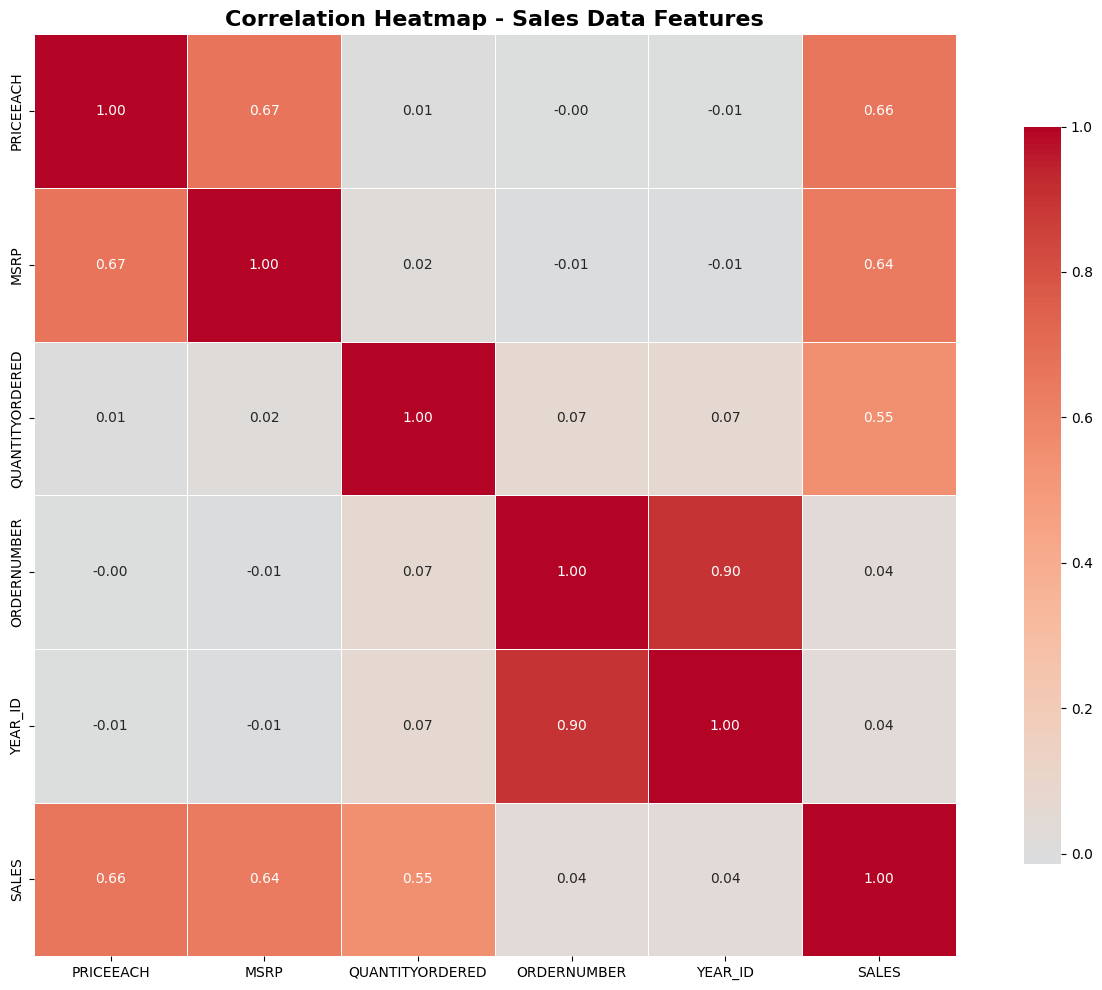

In [36]:
import seaborn as sns
# Calculate correlation matrix for numerical columns
correlation_matrix = data.corr(numeric_only=True)
# Create a larger figure for better visibility
plt.figure(figsize=(14, 10))
# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Sales Data Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [35]:
# Keep only columns with highest correlation + target variable
columns_to_keep = ['PRICEEACH', 'MSRP', 'QUANTITYORDERED', 'ORDERNUMBER', 'YEAR_ID', 'SALES']
data = data[columns_to_keep]

In [37]:
data.head()

,PRICEEACH,MSRP,QUANTITYORDERED,ORDERNUMBER,YEAR_ID,SALES
0,95.70,95,30,10107,2003,2871.00
1,81.35,95,34,10121,2003,2765.90
2,94.74,95,41,10134,2003,3884.34
3,83.26,95,45,10145,2003,3746.70
4,100.00,95,49,10159,2003,5205.27


In [39]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data.drop('SALES', axis=1)
y = data['SALES']

# Apply StandardScaler to features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [40]:
X_scaled.head(3)

,PRICEEACH,MSRP,QUANTITYORDERED,ORDERNUMBER,YEAR_ID
0,0.596978,-0.142246,-0.522891,-1.647947,-1.16517
1,-0.114450,-0.142246,-0.112201,-1.495888,-1.16517
2,0.549384,-0.142246,0.606505,-1.354689,-1.16517


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [ ]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

In [ ]:
# Create and fit the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

In [43]:
# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\nTraining Metrics:")
print(f"R² Score: {train_r2:.4f}")
print(f"MSE: {train_mse:.2f}")
print(f"MAE: {train_mae:.2f}")
print(f"RMSE: {np.sqrt(train_mse):.2f}")


Training Metrics:
R² Score: 0.8072
MSE: 606077.46
MAE: 552.03
RMSE: 778.51


In [ ]:
import joblib

# Save the trained Linear Regression model
model_filename = 'sales_forecasting_model.pkl'
joblib.dump(model, model_filename)
print(f"✓ Model saved successfully as '{model_filename}'")

# Also save the scaler for future use
scaler_filename = 'sales_scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✓ Scaler saved successfully as '{scaler_filename}'")

# Load the model back (for verification)
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
print(f"\n✓ Model and Scaler loaded successfully!")
print(f"Model type: {type(loaded_model)}")
print(f"Scaler type: {type(loaded_scaler)}")